# Exercises
This must be marked before you leave the lab. Mark weighting is in brackets. **Save your work to GitHub after having run all cells with `Runtime` -> `Restart and run all`. And do not change the notebook's filename.** Do add comments to your code, you'll lose points if your code is hard to understand. Graphs without labels (or units when appropriate) are not worth any point.

## Exercise 0

See LearningCentral for a video of integrating a function using the Monte Carlo method.

## Exercise 1

[4] Plot histograms using the uniform and normal distribution random number generators. Investigate how the histograms depend on the number of points
taken.

In [2]:
import numpy as np
from numpy.random import random, normal, seed
import matplotlib.pyplot as plt

The histograms better represent the distributions that the random numbers come from as you increase N


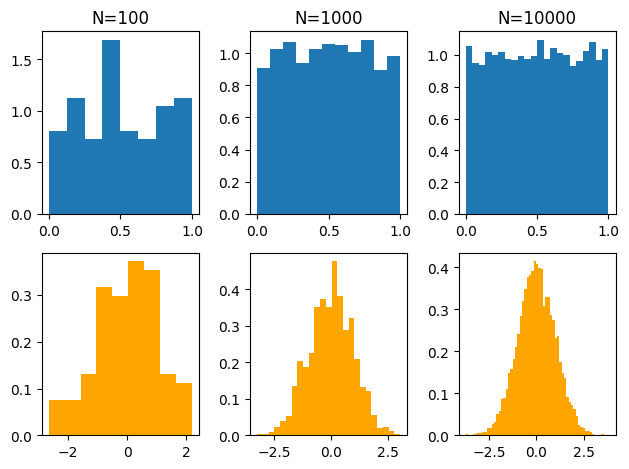

In [3]:
fig, ax = plt.subplots(2,3)

for i in range(3):
  # make the uniform random data
  N = int(10**(i+2)) # sets N to 100, 1000, and 10000
  x = random(N)
  # plot the uniform histogram for this N
  ax[0,i].hist(x, bins='auto',density=True);
  ax[0,i].set_title(f'N={N}')

  # make the normal random data
  x = normal(0,1,N)
  # plot the normal histogram for this N
  ax[1,i].hist(x, bins='auto',density=True, color='orange');

fig.tight_layout()
fig.show()

print('The histograms better represent the distributions that the random numbers come from as you increase N')

## Exercise 2

[7] Find $\pi$ using the method described in the introduction and plot a unit square to illustrate points which lie within the unit circle. It’s much faster to use the second method of making the random numbers, `x=random(N)`. You should plot data points within the circle in blue and those outside in green. Adapt code similar to that below to do the plotting.
```python
inpond = np.sqrt(x**2+y**2) <= 1.0 # True if in the pond
plt.plot(x[inpond==True], y[inpond==True],'b.')
```
 Compare the speed between using a `for` loop and using the vectorised `x=random(N)`.

pi calculated in: 0:00:00.158956ms using for loop method, pi = 3.13712
pi calculated in: 0:00:00.003232ms using vectorised method, pi = 3.1406


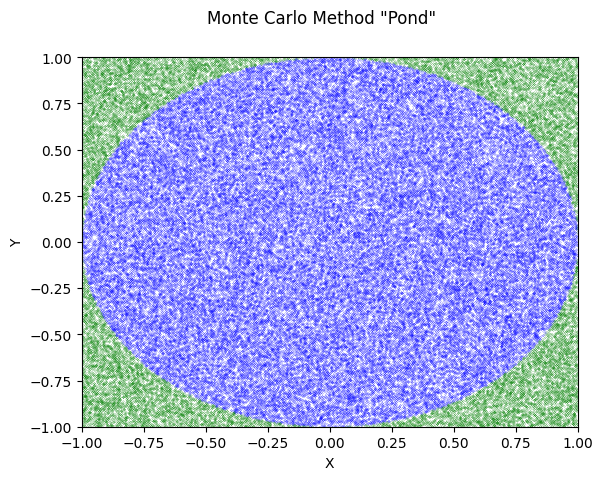

In [4]:
from datetime import datetime

N = int(1e5)

# calculate pi using the method above - for loop method, and time it
startTime = datetime.now()
x = np.zeros(N)
y = np.zeros(N)
for i in range(N):
  x[i] = 2*np.random.rand() - 1
  y[i] = 2*np.random.rand() - 1
n = np.sum(np.sqrt(x**2 +y **2) <= 1.0)
pi = 4*n/N
print(f'pi calculated in: {datetime.now()-startTime}ms using for loop method, pi = {pi}')

# random(N) method
startTime = datetime.now()
x, y = 2*np.random.rand(2, N) - 1
inpond = np.sqrt(x**2 +y **2) <= 1.0 # True if in the pond
n = np.sum(inpond)
pi = 4*n/N
print(f'pi calculated in: {datetime.now()-startTime}ms using vectorised method, pi = {pi}')

# plotting the data in the zone, and out of the zone
fig, ax = plt.subplots()
ax.plot(x[inpond], y[inpond],'b.', ms=0.3)
ax.plot(x[inpond==False], y[inpond==False],'g.', ms=0.3)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
fig.suptitle('Monte Carlo Method "Pond"')
fig.show()

## Exercise 3

[9] Integrate $f(x) = sin(x)tan(x)$ between $0$ and $\pi/4$ using the MC method, and compare with the exact answer (obtained for instance via [WolframAlpha](https://www.wolframalpha.com/)). Investigate what happens with increasing the number of points $N$ you use by plotting the MC answer versus number of points, choosing appropriate values for $N$ and choice of axes.

 To get full marks you must avoid using a loop in the integration (but you can loop over different values of $N$).

CPU times: user 7.66 s, sys: 118 ms, total: 7.78 s
Wall time: 7.82 s


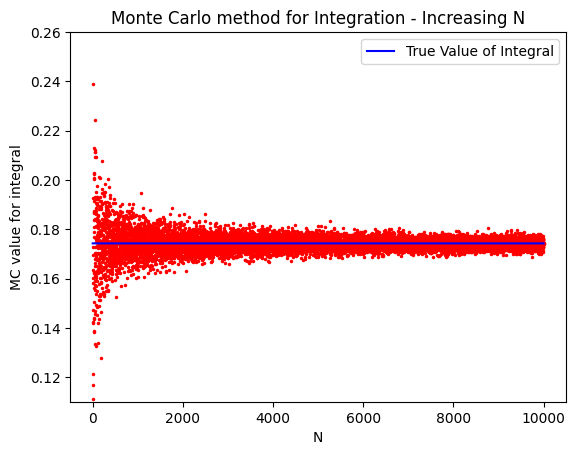

In [5]:
%%time

def f(x):
  '''
  defines the function as stated above
  '''
  return np.sin(x)*np.tan(x)

#set up figure
fig, ax = plt.subplots()

N=np.linspace(1, int(1e4), int(1e4), dtype=int) # generate an array of Ns from 1 to 10,000 in 100s

# loop through Ns and calculate the integral for each one
for n in N:
  x = np.pi/4 * np.random.rand(n) # define a random point in the range [0, π/4]
  s = np.sum(f(x)) # s is the sum of the random f points
  integral = np.pi/4 * s/n # integral = length of interval * sum of f(x) / N
  ax.plot(n, integral, 'r.', ms=3)

true_val = 0.17426680583299550083176496287494326974332439057316137416495573965801094499 # according to WolframAlpha; values should converge to this
# plot the true value as a horizontal line
ax.plot(N, true_val * np.ones_like(N), 'b-', label='True Value of Integral')

# display the plot
ax.set_xlabel('N')
ax.set_ylabel('MC value for integral')
ax.set_title('Monte Carlo method for Integration - Increasing N')
ax.set_ylim(0.11, 0.26)
ax.legend(loc='upper right')

fig.show()